In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = '/content/drive/My Drive/housing.csv'

df = pd.read_csv(file_path)



In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
#continous- longitude, laltitude, housing_median_age, household, median_income, median_house_value
#discrete - population, total_bedrooms
df.info() #data ko type ko information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

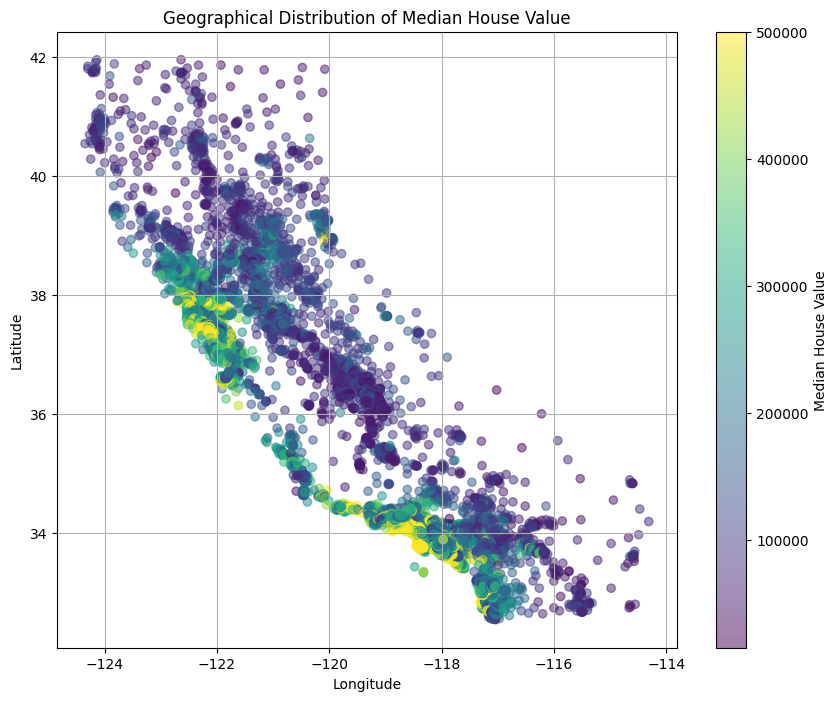

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Median House Value')
plt.grid(True)
plt.show()

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show plot
plt.show()

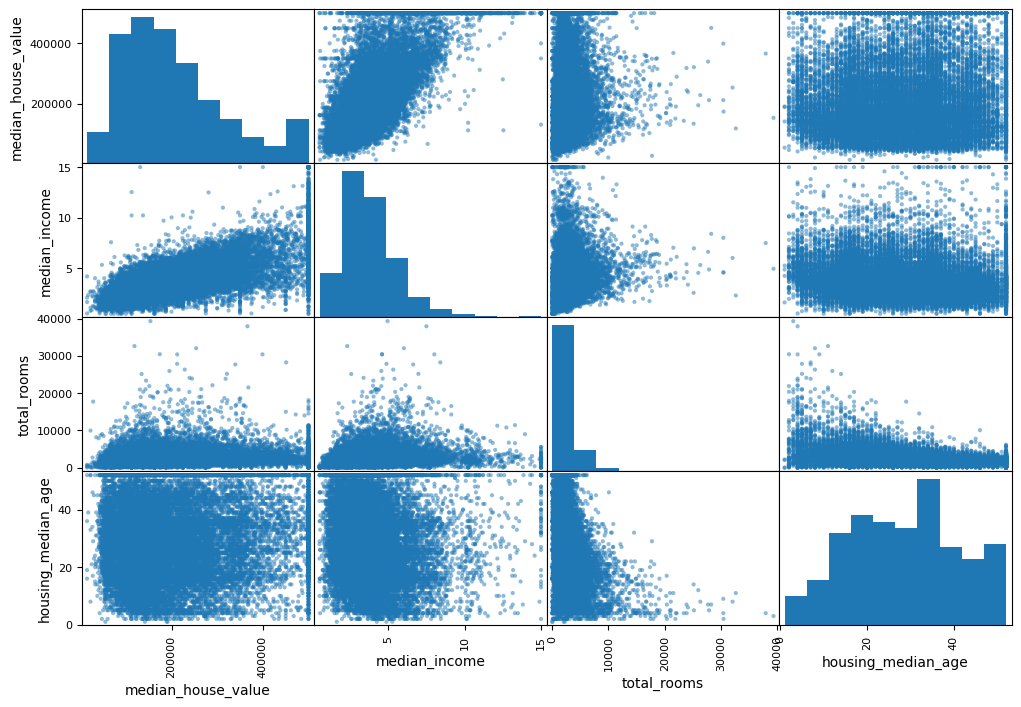

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
 "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

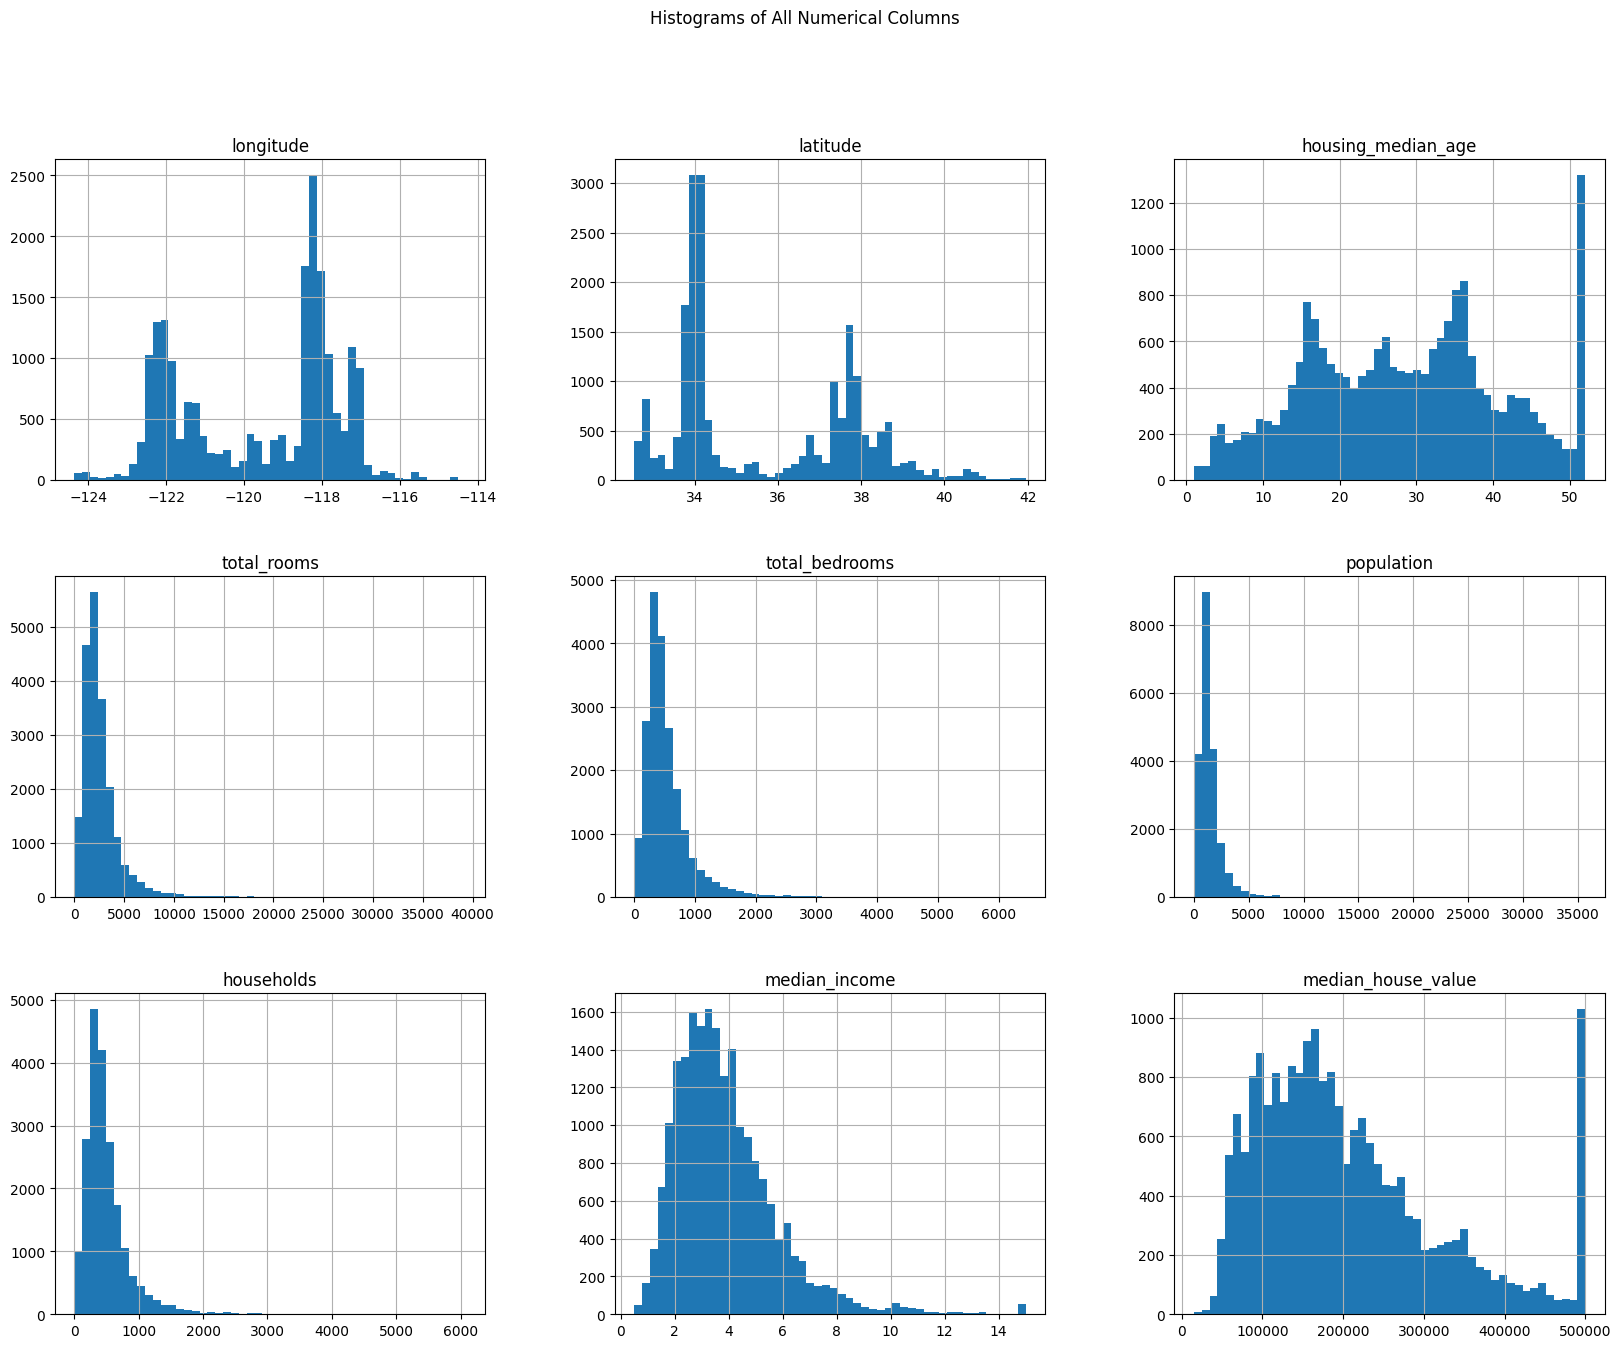

In [ ]:
df.hist(bins=50, figsize=(20, 15)) #size start 50 bars with 20width and 15 height
plt.suptitle('Histograms of All Numerical Columns')
plt.show()

In [ ]:
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


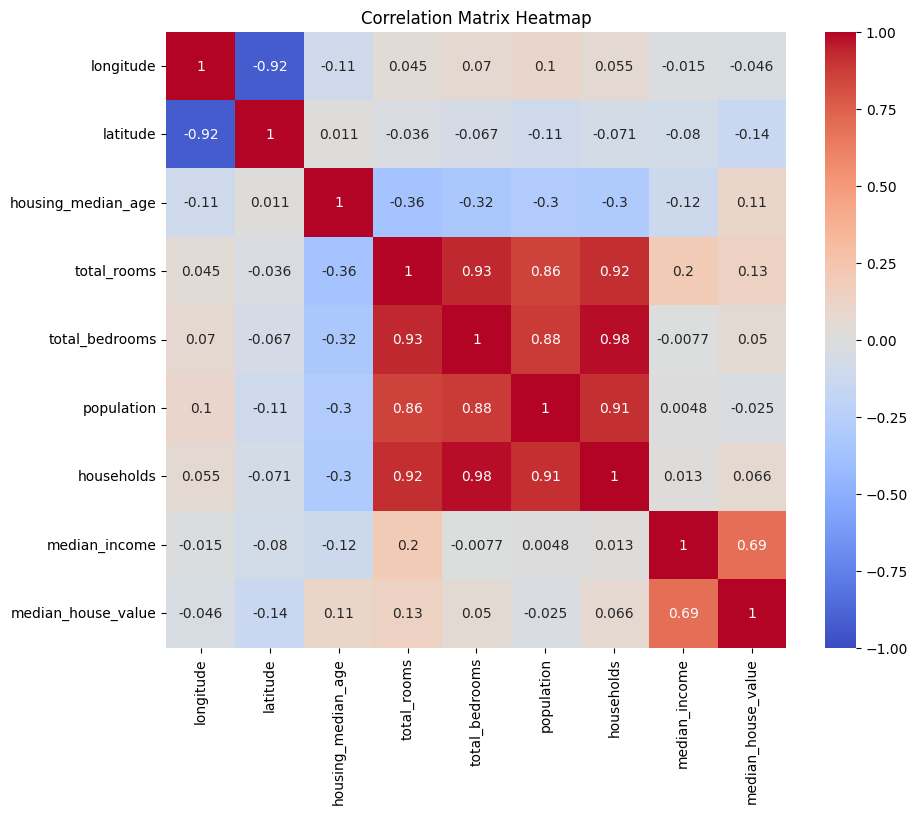

In [ ]:
import seaborn as sns

df_numeric = df.select_dtypes(include=[float, int])

# Calculate the correlation matrix
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

# find the null value and deal with it. then normalize the data.

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder()
encoded_features = onehot_encoder.fit_transform(df[['ocean_proximity']]).toarray()
encoded_df = pd.DataFrame(encoded_features, columns=onehot_encoder.get_feature_names_out(['ocean_proximity']))
data = df.join(encoded_df)

In [ ]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0


In [ ]:
DROP = ['longitude', 'latitude', 'ocean_proximity']
data = data.drop(DROP, axis = 1)

In [ ]:
data.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
data.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')
df_imputed = imputer.fit_transform(data)


In [ ]:
df_imputed

array([[4.100e+01, 8.800e+02, 1.290e+02, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [2.100e+01, 7.099e+03, 1.106e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [5.200e+01, 1.467e+03, 1.900e+02, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       ...,
       [1.700e+01, 2.254e+03, 4.850e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.800e+01, 1.860e+03, 4.090e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.600e+01, 2.785e+03, 6.160e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00]])

In [ ]:
df_imputed = pd.DataFrame(df_imputed, columns=data.columns)

In [ ]:
df_imputed.isnull().sum()

,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity_<1H OCEAN,0
ocean_proximity_INLAND,0
ocean_proximity_ISLAND,0


after completing null value and normalization. handle categorical data

In [ ]:
df_imputed.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#normalize the data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df_imputed)

In [ ]:
scaled_data = pd.DataFrame(scaled_data, columns= df_imputed.columns)
scaled_data.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.631579,-0.733422,-0.883755,-0.899787,-0.870769,2.197582,1.880448,0.0,0.0,0.0,1.0,0.0
1,-0.421053,2.924276,1.937906,1.316631,2.243077,2.186664,1.232041,0.0,0.0,0.0,1.0,0.0
2,1.210526,-0.388178,-0.707581,-0.714286,-0.713846,1.707732,1.187941,0.0,0.0,0.0,1.0,0.0
3,1.210526,-0.501691,-0.577617,-0.648188,-0.584615,0.967177,1.113523,0.0,0.0,0.0,1.0,0.0
4,1.210526,-0.294074,-0.447653,-0.640725,-0.461538,0.142854,1.119724,0.0,0.0,0.0,1.0,0.0


then split the data

In [ ]:
from sklearn.model_selection import train_test_split
x = scaled_data.drop(columns= ['median_house_value']) #dependent variable hatauni - indepedent matra huncha
y = scaled_data['median_house_value'] #y ma y ma matra huni variable -- yesma dependent variable matra
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
 #0.2- 20% y= dependent variable x= independent variable --y = mx+ c

x.head()



,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.631579,-0.733422,-0.883755,-0.899787,-0.870769,2.197582,0.0,0.0,0.0,1.0,0.0
1,-0.421053,2.924276,1.937906,1.316631,2.243077,2.186664,0.0,0.0,0.0,1.0,0.0
2,1.210526,-0.388178,-0.707581,-0.714286,-0.713846,1.707732,0.0,0.0,0.0,1.0,0.0
3,1.210526,-0.501691,-0.577617,-0.648188,-0.584615,0.967177,0.0,0.0,0.0,1.0,0.0
4,1.210526,-0.294074,-0.447653,-0.640725,-0.461538,0.142854,0.0,0.0,0.0,1.0,0.0


In [ ]:
y.head()

,median_house_value
0,1.880448
1,1.232041
2,1.187941
3,1.113523
4,1.119724


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize linear regression model
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

# Predict on the training set
y_train_pred = model.predict(x_train)

# Predict on the testing set
y_test_pred = model.predict(x_test)

# Evaluate the model (for example, using Mean Squared Error)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")



Train MSE: 0.23000350070882775
Test MSE: 0.2388509488108468
